In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# **Logistic Regression - Логистическая регрессия**

**Алгоритм *классификации* для предсказания значений *категориальных* переменных**

Логистическая регрессия позволяет предсказывать значения категориальной переменной на основе исторических данных.

Целевая категориальная переменная может принимать два или более дискретных значений (классов)

Пример - указать дял картинки один из классов:
- Класс 0: изображение автомобиля
- Класс 1: изображение природы
- Класс 2: изображение еды 

Непрерывные переменные можно преобразовать в дискретные с помощью диапазонов (buckets) - дискретизация:

- Класс 0: цена дома $0-100k

- Класс 1: цена дома $100-200k

- Класс 2: цена дома $200+k

Непрерывная --> категориальная

Категориальная --> непрерывная уже нельзя без исходных данных

Зачастую алгоритмы на выходе дают *вероятность* принадлежности к тому или иному классу

- Класс 0: 15%
- Класс 1: 80%
- Класс 2: 5%

Для дискретных переменных мы не сможем посчитать метрики отклонения $y - y_(hat)$

## **Логистическая функция**

Логистическая регрессия получается преобразованием линейной регрессии в модель классификации с помощью 

*логистической функции/ сигмоид-функции*

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Как можно перевести модель линейной регрессии для *задачи регрессии* в логистическую модель для *задачи классификации*

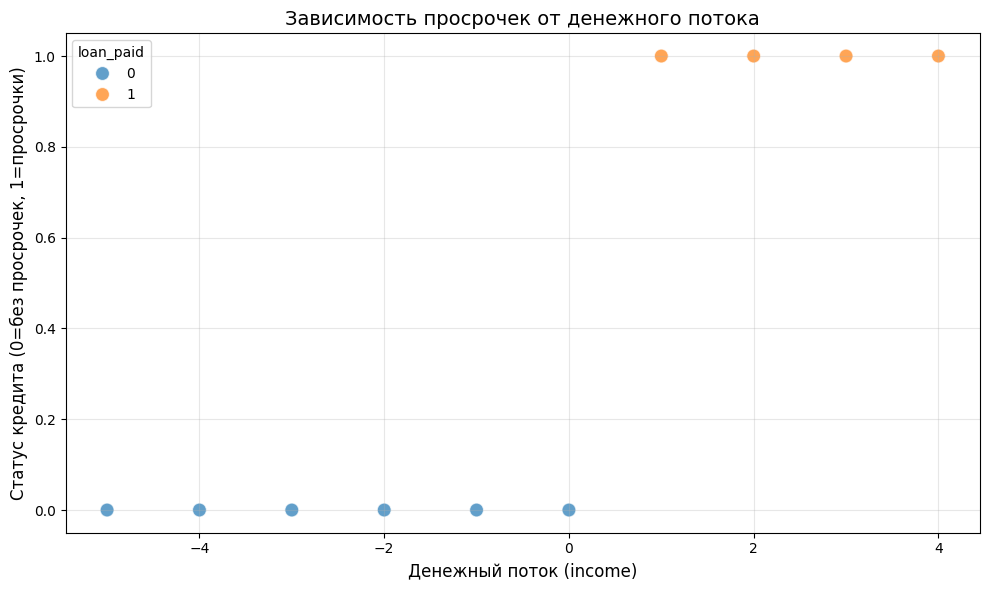

In [2]:
# Пример данных
data = pd.DataFrame({
    'income': [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4],
    'loan_paid': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='income', y='loan_paid', 
                hue='loan_paid',
                s=100, alpha=0.7)

plt.xlabel('Денежный поток (income)', fontsize=12)
plt.ylabel('Статус кредита (0=без просрочек, 1=просрочки)', fontsize=12)
plt.title('Зависимость просрочек от денежного потока', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Попробуем построить Линейную регрессию для этих данных

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
X = data[['income']]
y = data[['loan_paid']]

model = LinearRegression()
model.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
model.coef_, model.intercept_

(array([[0.14545455]]), array([0.47272727]))

In [6]:
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_line = model.predict(x_line)

C:\Users\Надежда\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


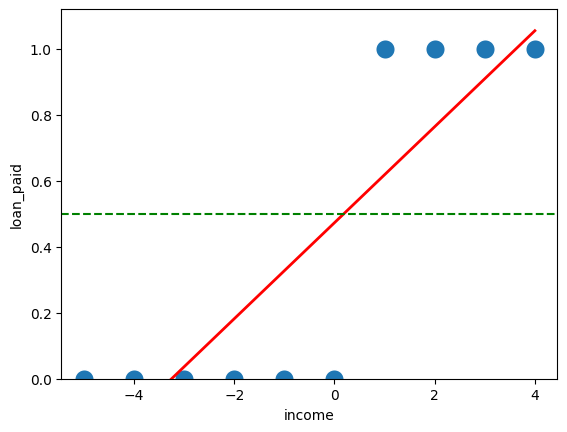

In [7]:
plt.figure()
plt.plot(x_line, y_line, color='red', lw=2)
sns.scatterplot(data=data, y='loan_paid', x='income', s=200)
plt.ylim(bottom=0)
plt.axhline(y=0.5,c='green', ls='--')

Будем считать ось ординат как вер-ть принадлежности к классу y=1 - P(y=1)
P(y=1)=0.5 - точка отсечки дял классификации

Переход от *Линейной регрессии* к **Логистической регрессии**

Уравнение линейной регрессии

$$
\hat{y} = \beta_0 + \sum_{i=1}^n \beta_i x_i
$$

Логистическая функция

Оно возвращает 0/1 или какое-то значение, которое мы можем интерпретировать как вероятность попадания в тот или иной класс

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Достаточно подставить уравнение линейной регрессии в логистическую функцию, и получится *Логистическая регрессия*

$$
\hat{y} = \sigma(\beta_0 x_0 + \cdots + \beta_n x_n)
$$

$$
\hat{y} = \sigma\left(\sum_{i=0}^n \beta_i x_i\right)
$$

Формула **Логистической регрессии**

$$
\hat{y} = \frac{1}{1 + e^{-\sum_{i=0}^n \beta_i x_i}}
$$

**Odds (шансы)** события с вероятностью **р** вычисляется как вероятность возникновения этого события, деленная как вероятность невозникновения этого события

$$
\frac{p}{1-p}
$$

Шансы 10 к 1 - это про выше указанную формулу

## **Логистическая регрессия в Scikit-Learn**

- age - возраст
- physical_score - оценка физического здоровья
- test_result - аудио-тест пройден=1б не пройден=0

In [2]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\hearing_test.csv")

In [3]:
df.shape

(5000, 3)

In [4]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [6]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [7]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='test_result', ylabel='count'>

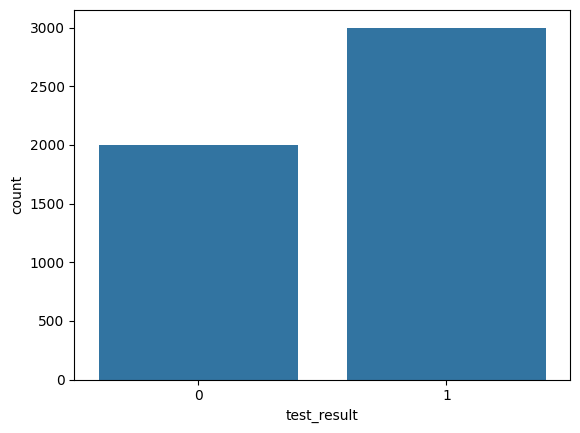

In [8]:
sns.countplot(data=df, x='test_result')

<Axes: xlabel='test_result', ylabel='age'>

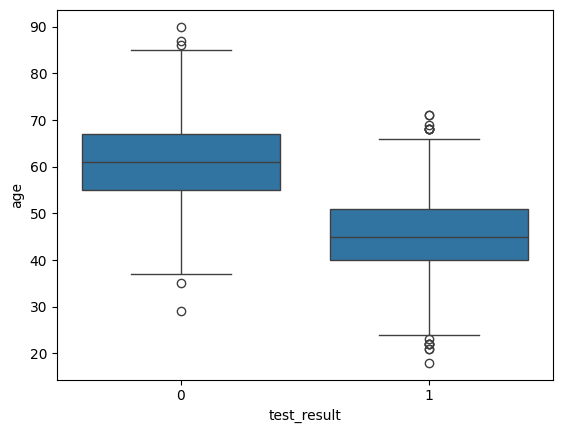

In [9]:
sns.boxplot(data=df, x='test_result', y='age')

<Axes: xlabel='test_result', ylabel='physical_score'>

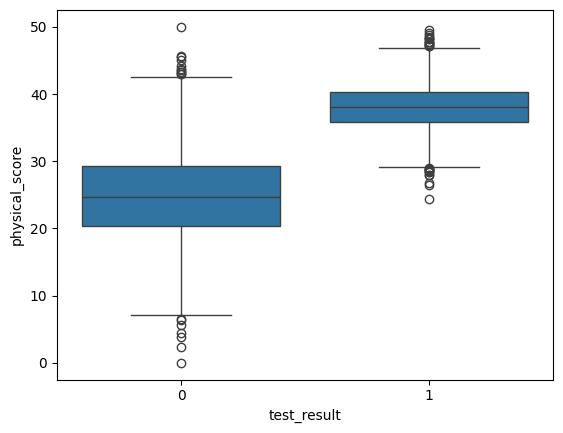

In [10]:
sns.boxplot(data=df, x='test_result', y='physical_score')

<Axes: xlabel='age', ylabel='physical_score'>

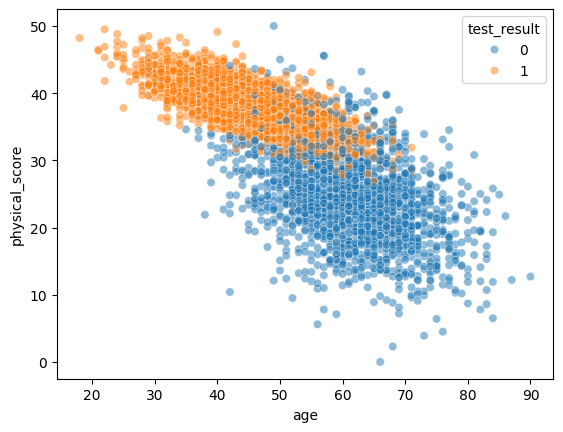

In [11]:
plt.figure(dpi=100)
sns.scatterplot(data=df,x='age',y='physical_score', hue='test_result', alpha=0.5)

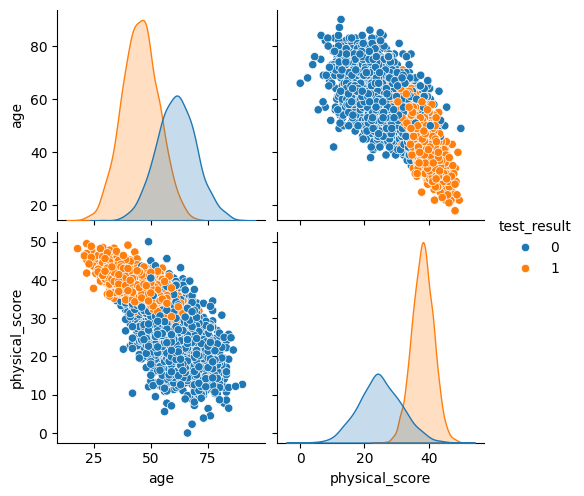

In [12]:
sns.pairplot(data=df,hue='test_result')

<Axes: >

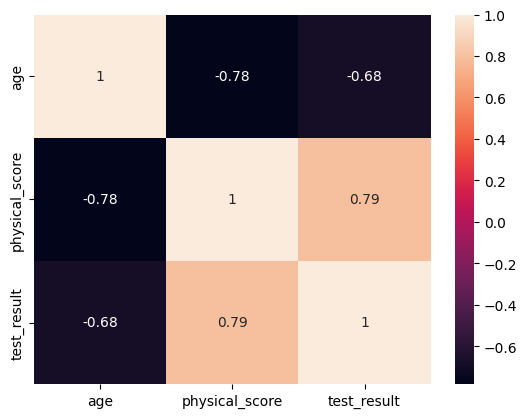

In [13]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='physical_score', ylabel='test_result'>

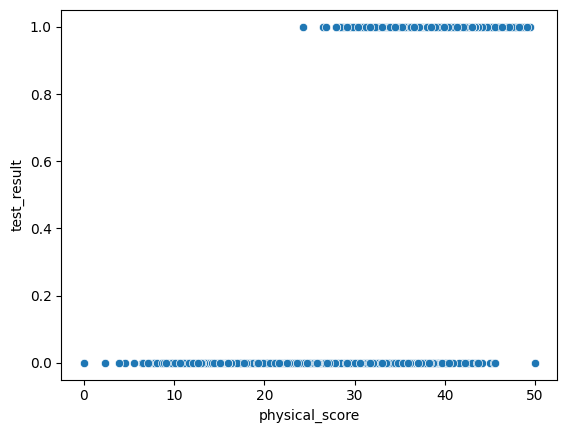

In [14]:
sns.scatterplot(data=df, x='physical_score',y='test_result')
# здесь лучше использовать boxplot, test_result=[0,1]

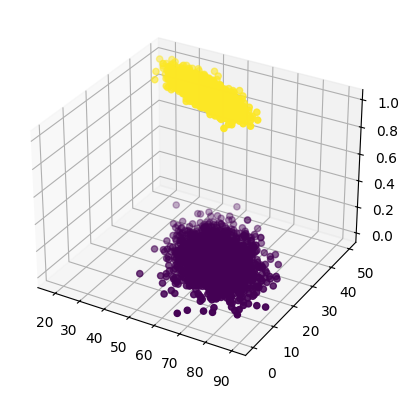

In [15]:
fig=plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(df['age'],df['physical_score'], df['test_result'], c=df['test_result'])

In [16]:
X = df.drop('test_result', axis=1)
y=df['test_result']

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [19]:
scaler = StandardScaler()

In [20]:
scaled_X_train = scaler.fit_transform(X_train)

In [21]:
scaled_X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
log_model = LogisticRegression()

In [24]:
log_model.fit(scaled_X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
log_model.coef_

array([[-0.95017725,  3.46148946]])

In [26]:
y_pred = log_model.predict(scaled_X_test)

In [27]:
y_pred_proba = log_model.predict_proba(scaled_X_test)

In [28]:
#y_pred_proba
# вероятность принадлежности к классам 0 и 1 соответственно

## **Метрики оценки модели классификации**

***Confusion Matrix - Матрица ошибок***

False Negative, False Positive - то, что я слушала на машинном..

Вспоминаем задачи с ЕГЭ из первой части

Человек болеет - Тест + = **True Positive**

*Человек болеет - Тест -* = **False Negative**

Человек НЕ болеет - Тест - **True Negative**

*Человек НЕ болеет - Тест +* **False Positive**

Понятие матрицы ошибок

Результаты с True мы хотим *максимизировать*

***Accuracy - Доля правильно классифицированных объектов***

$$
Accuracy = \frac{(TP+TN)}{Total}
$$

Несбалансированные классы приводят к **проблеме парадокса accuracy**, т.е. к *искаженным (завышенным) результатам*

(Заболел небольшой % населения, мошенничество затронуло небольшой % кредиток и т.д.)

Если 1 из 2 классов имеет небольшой процент n%, то модель, предсказывающая "основной" класс, будет accuracy (1-n)

***Recall - показывает, какую долю всех реальных положительных случаев модель смогла правильно обнаружить, отвечая на вопрос: «Сколько из всех существующих положительных примеров модель нашла?»***
$$
Recall = \frac{TP}{(TP + FN)}
$$

Из всех  положительных случаев какой процент этих случаев был обнаружен?

***Precision - доля правильно предсказанных положительных объектов среди всех объектов, предсказанных положительным классом***

$$
Precision = \frac{TP}{(TP+FP)}
$$

Precision и Recall позволяют оценить работу модели именно для **положительных** случаев

Очень часто между этими моделями нужно искать некоторый баланс

Precision и Recall связаны одним числителем TP, имеет смысл вычислить среднее гармоническое
$$
F1-Score = \frac{2 * Precision * Recall}{Precision + Recall}
$$

F1-Score равен 0, если Precision или Recall равны 0

### **ROC-кривая**

Receiver Operator Characteristic

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
y_test

1718    1
2511    1
345     0
2521    1
54      0
       ..
4770    1
188     1
3335    0
4583    0
3208    0
Name: test_result, Length: 500, dtype: int64

In [32]:
#y_pred

In [34]:
accuracy_score(y_test, y_pred)
# в 93% случаев наша модель парвильно предсказывает принадлежность к классу

0.93

In [35]:
confusion_matrix(y_test, y_pred)

array([[172,  21],
       [ 14, 293]])

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

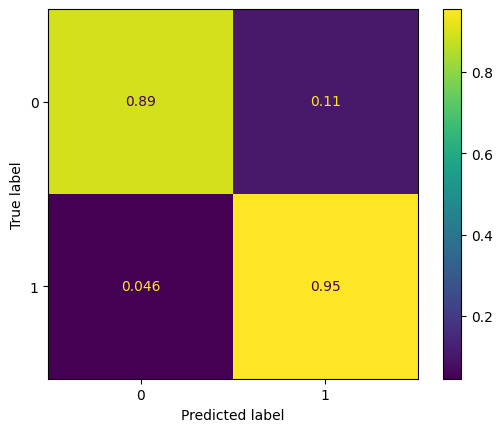

In [39]:
ConfusionMatrixDisplay.from_estimator(log_model, scaled_X_test, y_test, normalize='true')

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



In [42]:
from sklearn.metrics import precision_score, recall_score

In [43]:
precision_score(y_test, y_pred)

0.9331210191082803

In [44]:
recall_score(y_test, y_pred)

0.9543973941368078

Графики ROC и recall и precision

In [45]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

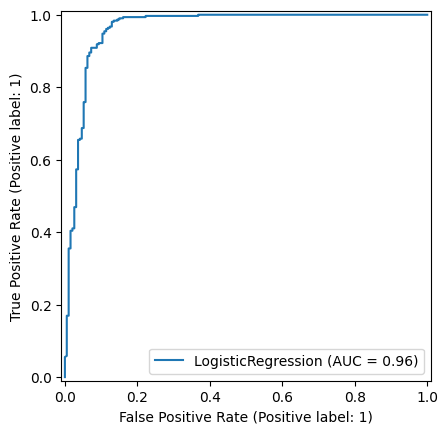

In [49]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test, ax=ax)

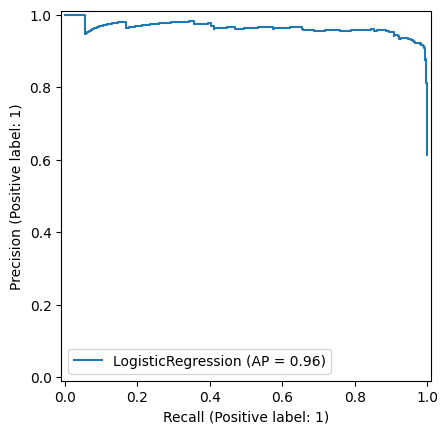

In [50]:
PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test)

## **Мультиклассовая классификация**

In [2]:
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()

In [4]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [6]:
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)


In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='species', ylabel='count'>

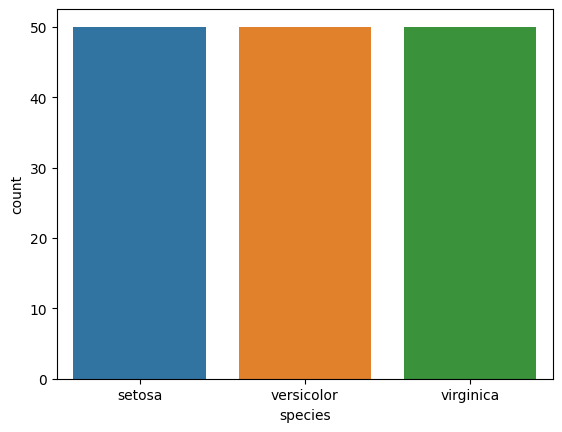

In [74]:
sns.countplot(data=df, x='species', hue='species')

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

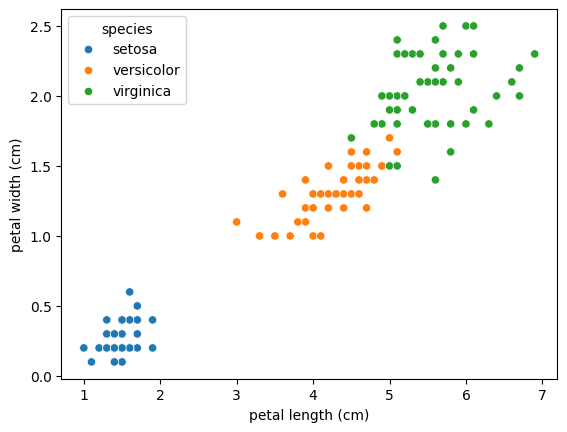

In [77]:
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species')

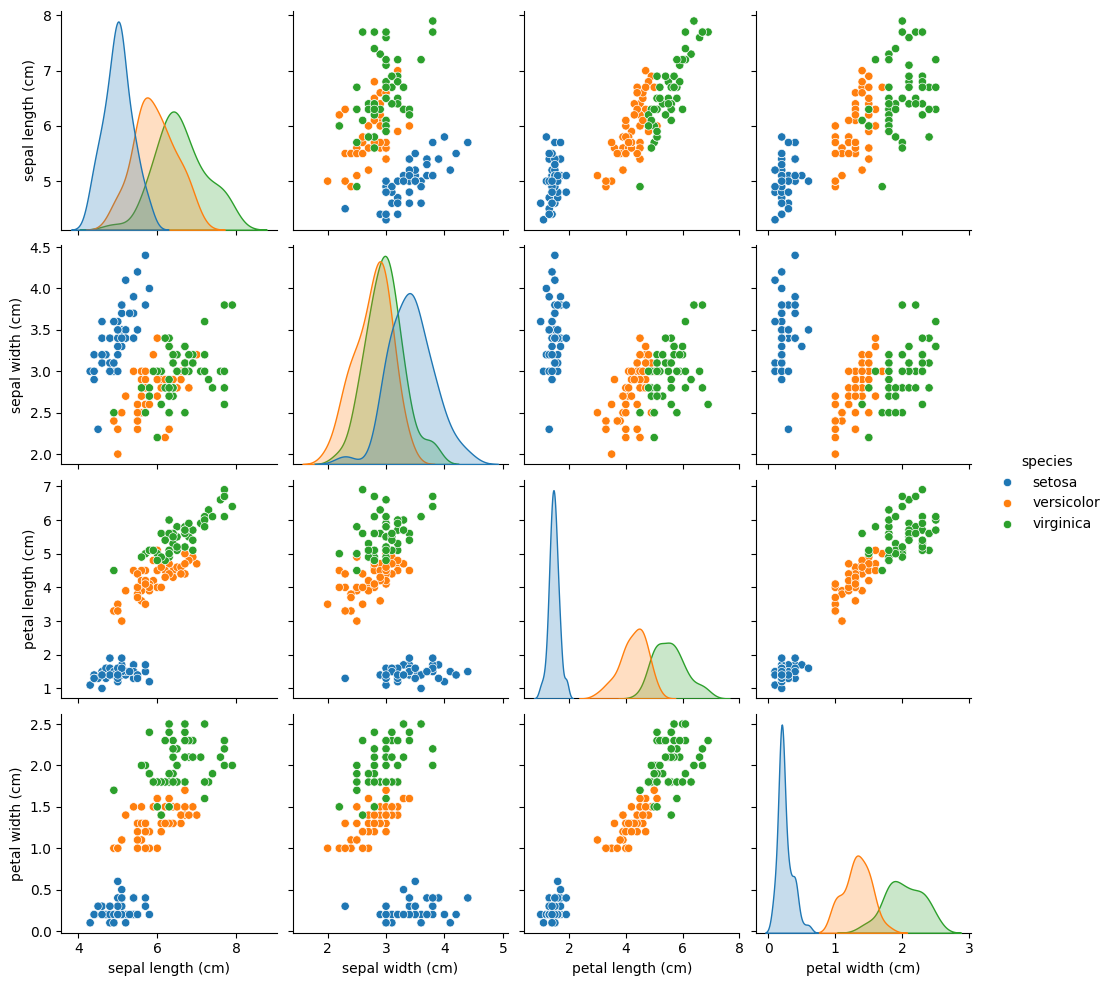

In [79]:
sns.pairplot(data=df, hue='species')

<Axes: >

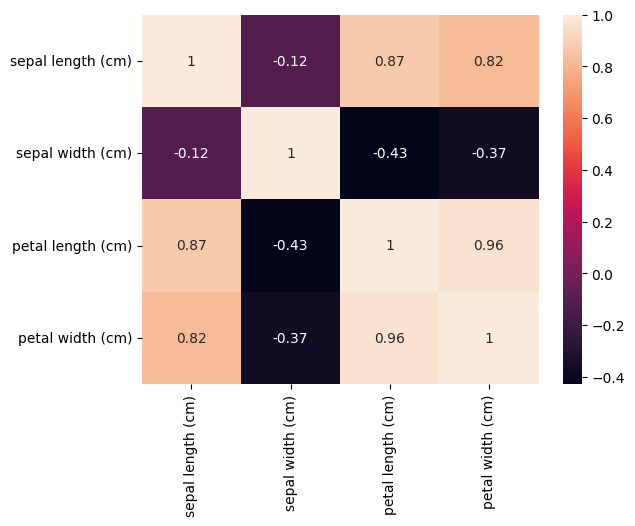

In [81]:
sns.heatmap(df.drop('species', axis=1).corr(), annot=True)

In [10]:
X = df.drop('species', axis=1)
y = df['species']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [13]:
scaler = StandardScaler()

In [14]:
scaled_X_train = scaler.fit_transform(X_train)

In [29]:
scaled_X_test = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

In [18]:
from sklearn.model_selection import GridSearchCV

In [19]:
log_model = LogisticRegression(solver='saga', max_iter=5000)

In [20]:
penalty = ['l1', 'l2', 'elasticnet']
l1_ratio = np.linspace(0,1,20)
C = np.logspace(0,1,20)
param_grid = {'penalty':penalty,
             "l1_ratio":l1_ratio,
             'C': C}

In [21]:
grid_model =GridSearchCV(log_model, param_grid=param_grid)

In [23]:
# best params are l1_ratio=1.1, penalty='l1', C=11.28837891684689

In [26]:
log_model_best = LogisticRegression(solver='saga', l1_ratio=0.0, penalty='l1', C=11.28837891684689, max_iter=5000)

In [27]:
log_model_best.fit(scaled_X_train, y_train)

C:\Users\Надежда\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",11.28837891684689
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [40]:
log_model_best.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [30]:
y_pred = log_model_best.predict(scaled_X_test)

In [31]:
y_pred

array(['setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'setosa', 'virginica', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'versicolor', 'versicolor', 'versicolor'], dtype=object)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [33]:
accuracy_score(y_test, y_pred)

1.0

In [34]:
confusion_matrix(y_test, y_pred)

array([[10,  0,  0],
       [ 0, 17,  0],
       [ 0,  0, 11]])

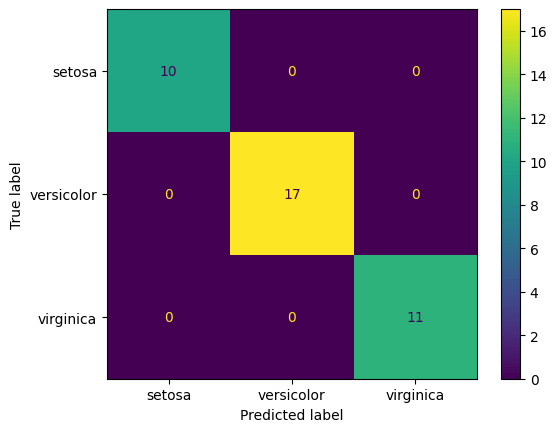

In [35]:
ConfusionMatrixDisplay.from_estimator(log_model_best, scaled_X_test, y_test)

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        17
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [37]:
from sklearn.metrics import roc_curve, auc

In [38]:
def plot_multiclass_roc(clf, X_test, y_test, n_classes, figsize=(5,5)):
    y_score = clf.decision_function(X_test)

    # создаём пустые структуры
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # один раз вычисляем dummies 
    y_test_dummies = pd.get_dummies(y_test, drop_first=False).values
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_dummies[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # roc для каждого класса
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic example')
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f) for label %i' % (roc_auc[i], i))
    ax.legend(loc="best")
    ax.grid(alpha=.4)
    sns.despine()
    plt.show()

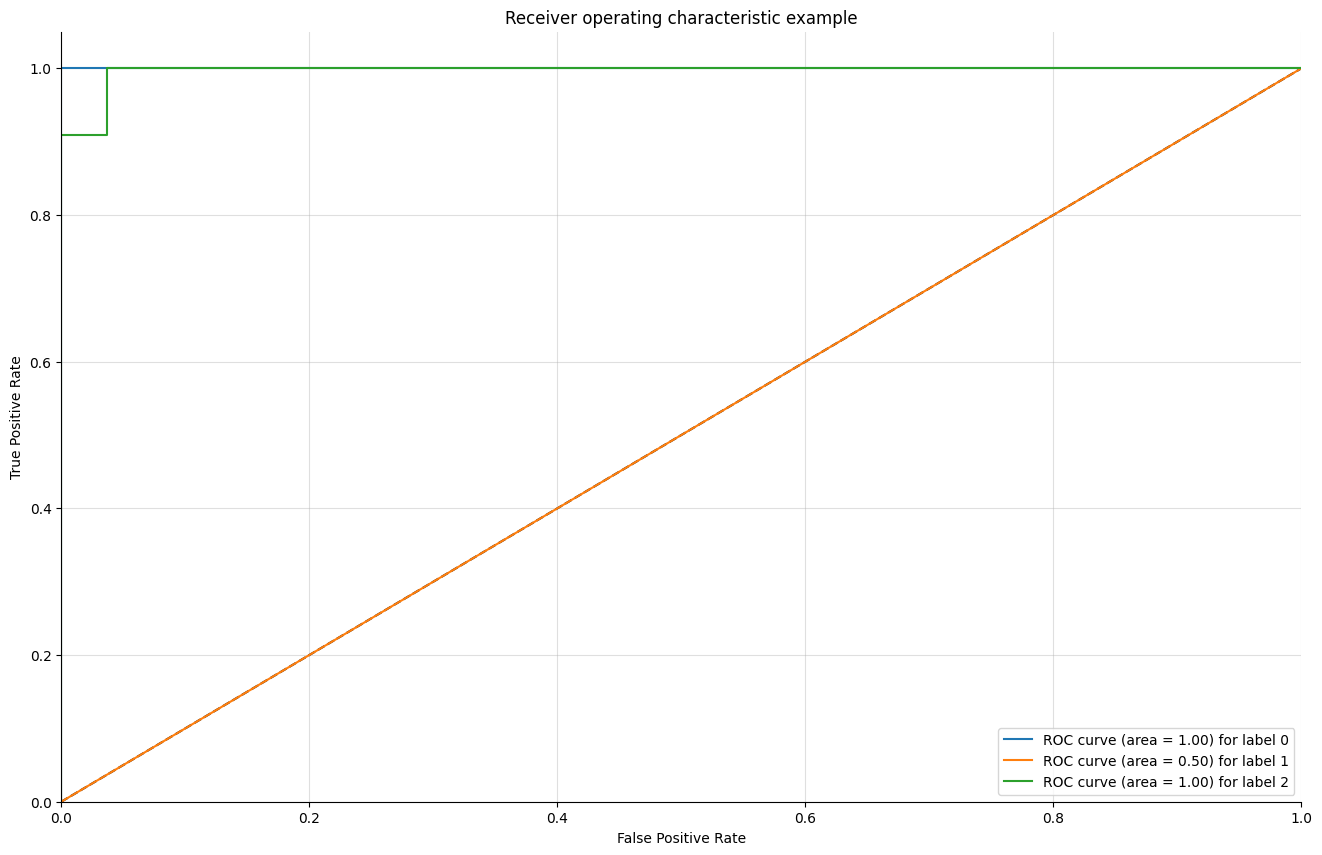

In [39]:
plot_multiclass_roc(grid_model, scaled_X_test, y_test, n_classes=3, figsize=(16, 10))